In [47]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
db = sqlite3.connect("sales_data.db")
cur = db.cursor()

print("Database Connected")

Database Connected


In [49]:
cur.execute("""
CREATE TABLE IF NOT EXISTS sales(
product TEXT,
quantity INTEGER,
price REAL
)
""")

db.commit()

print("Table Created")

Table Created


In [50]:
cur.execute("DELETE FROM sales")

sales = [
("Laptop",2,50000),
("Laptop",1,50000),
("Mouse",5,500),
("Keyboard",3,1000),
("Mouse",4,500),
("Keyboard",2,1000)
]

cur.executemany("INSERT INTO sales VALUES(?,?,?)",sales)

db.commit()

print("Data Added")

Data Added


In [51]:
sql = """
SELECT
product,
SUM(quantity) AS Total_Quantity,
SUM(quantity*price) AS Revenue
FROM sales
GROUP BY product;
"""

result = pd.read_sql_query(sql,db)

print(result)

    product  Total_Quantity   Revenue
0  Keyboard               5    5000.0
1    Laptop               3  150000.0
2     Mouse               9    4500.0


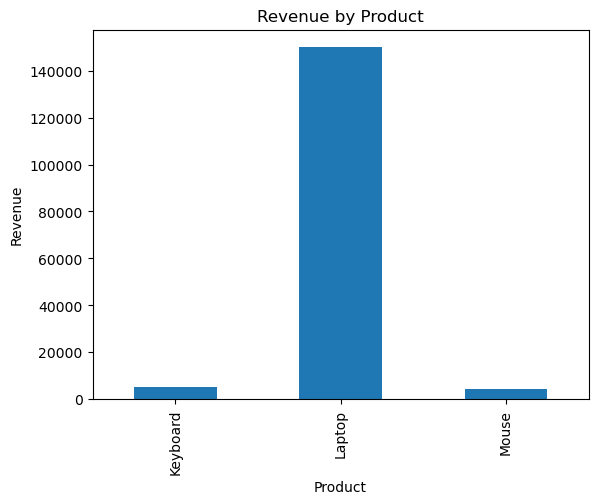

In [52]:
result.plot(
kind="bar",
x="product",
y="Revenue",
legend=False
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.savefig("sales_chart.png")

plt.show()

In [53]:
db.close()

print("Database Closed")

Database Closed
